In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

%matplotlib inline

# ADAPT THIS TO THE FILEPATH OF YOUR PARQUET FILE #
df = pd.read_parquet('nlp.parquet')

print('shape:', df.shape)
print('widths:     ', sorted(df['width'].unique()))
print('batch sizes:', sorted(df['batch_size'].unique()))
print('peak_lrs:   ', sorted(df['peak_lr'].unique()))
print('seeds:      ', sorted(df['seed'].unique()))

shape: (24349366, 13)
widths:      [256, 512, 1024, 2048, 2560]
batch sizes: [32, 64, 128, 256, 512, 1024, 2048]
peak_lrs:    [0.00048828125, 0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625]
seeds:       [111]


In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
TOKENS_PER_SAMPLE = 1024  # sequence length
WIDTH = 1024
SEED  = 111
SMOOTHING_WINDOW = 32     # set to 1 to disable

# (batch_size, peak_lr, label, color)
selected_configs = [
    (128,  0.001953125, r"BS=$2^{17}$, LR=$2^{-9}$",  "#0077BB"),
    (256,  0.00390625,  r"BS=$2^{18}$, LR=$2^{-8}$",  "#EE7733"),
    (512,  0.00390625,  r"BS=$2^{19}$, LR=$2^{-8}$",  "#009988"),
    (1024, 0.0078125,   r"BS=$2^{20}$, LR=$2^{-7}$",  "#CC3311"),
    (2048, 0.00390625,  r"BS=$2^{21}$, LR=$2^{-8}$",  "#EE3377"),
    # different validation loss example
    (128,  0.015625,    r"BS=$2^{17}$, LR=$2^{-6}$",  "#CCCCCC"),
]

def smooth(values, window):
    if window <= 1:
        return values
    out = np.convolve(values, np.ones(window) / window, mode='valid')
    pad = [np.mean(values[:i+1]) for i in range(len(values) - len(out))]
    return np.concatenate([pad, out])

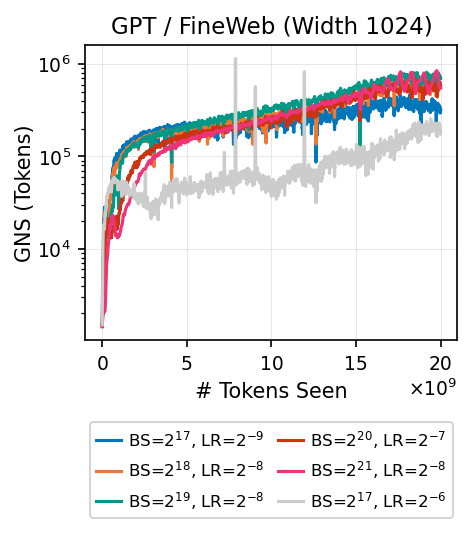

In [ ]:
# ── Plot settings ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'lines.linewidth': 1.5,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

X_COL = 3.25
fig, ax = plt.subplots(figsize=(X_COL, X_COL * 1.2))

for bs, lr, label, color in selected_configs:
    run = df[
        (df['width'] == WIDTH) & (df['seed'] == SEED) &
        (df['batch_size'] == bs) & (df['peak_lr'] == lr) &
        df['gns'].notna() & np.isfinite(df['gns']) & (df['gns'] < 1e10)
    ].sort_values('samples_seen')

    if run.empty:
        print(f'No data: {label}')
        continue

    # adaptive smoothing: larger window for smaller batch sizes
    base_bs = 1024
    window = int(base_bs / bs) * SMOOTHING_WINDOW if bs < base_bs else SMOOTHING_WINDOW

    tokens = run['samples_seen'].values * TOKENS_PER_SAMPLE
    gns    = smooth(run['gns'].values, window) * TOKENS_PER_SAMPLE

    ax.plot(tokens, gns, color=color, label=label)

ax.set_xlabel('# Tokens Seen')
ax.set_ylabel('GNS (Tokens)', labelpad=1)
ax.set_title('GPT / FineWeb (Width 1024)', fontweight='medium')
ax.set_yscale('log')

ax.xaxis.set_major_locator(FixedLocator([0, 5e9, 10e9, 15e9, 20e9]))
ax.xaxis.set_major_formatter(FixedFormatter(['0', '5', '10', '15', '20']))
ax.text(1.0, -0.13, r'$\times 10^9$', transform=ax.transAxes, fontsize=9, ha='right', va='top')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=2, columnspacing=0.8, handlelength=1.5,
          handletextpad=0.4, frameon=True)

fig.tight_layout()
plt.savefig('nlp_temperature_comparison.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()